## define parameters

In [1]:
T1 = "2023-01-16T04:53:33.9" # http://odahub.io/ontology#StartTime
T2 = "2023-01-16T04:55:33.9" # http://odahub.io/ontology#EndTime
detection_time_scales = "1,10"
lc_time_scale = 0.1 # https://odahub.io/ontology#TimeIntervalSeconds
background_age = 10 # oda:TimeIntervalSeconds
min_sn = 5 # https://odahub.io/ontology#SignalToNoiseRatio
required_completeness = 0.3 # https://odahub.io/ontology#Float
global_snr_threshold = 3.0 # https://odahub.io/ontology#Float
negative_excesses = 0 # https://odahub.io/ontology#Integer

## import modules and prepare logger
the logger is a technical passage

In [2]:
import numpy as np
from astropy.time import Time
# from oda_api.data_products import LightCurveDataProduct, BinaryData, PictureProduct
from matplotlib import pylab as plt
from scipy import stats
from pprint import pprint

In [3]:
import logging
logging.getLogger().setLevel(logging.INFO)
#logging.getLogger().setLevel(logging.DEBUG) #for more verbose logging

logging.getLogger('').addHandler(logging.StreamHandler()) 
logger = logging.getLogger()
# from oda_api.api import ProgressReporter
# pr = ProgressReporter()
# pr.report_progress(stage='Initializing', progress=5)

## Get the SPI-ACS lightcurve from online service

In [4]:
from oda_api.api import DispatcherAPI
disp=DispatcherAPI(url='https://www.astro.unige.ch/mmoda//dispatch-data', instrument='mock')

par_dict={
    "T1": T1,
    "T2": T2,
    "T_format": "isot",
    "instrument": "spi_acs",
    "product": "spi_acs_lc",
    "product_type": "Real",
    "time_bin": lc_time_scale,
    "time_bin_format": "sec",
}

data_collection = disp.get_product(**par_dict)

lc = data_collection.spi_acs_lc_0_query.data_unit[1].data

please beware that by default, in a typical setup, oda_api will not output much. To learn how to increase the verbosity, please refer to the documentation: https://oda-api.readthedocs.io/en/latest/user_guide/ScienceWindowList.html?highlight=logging#Let's-get-some-logging . 
To disable this message you can pass `.get_product(..., silent=True)`
- waiting for remote response (since 2026-05-27 14:20:49), please wait for https://www.astro.unige.ch/mmoda//dispatch-data/run_analysis
session: V4ZJBS30T5TMOU01 job: 9a2da5508bbc397b

... query status prepared => done
... assigned job id: 9a2da5508bbc397b
query COMPLETED SUCCESSFULLY (state done)
query complete: terminating


In [5]:
lc 

array([(-59.9500451 , 95600., 977.75252493),
       (-59.8500447 , 95100., 975.19228873),
       (-59.75004524, 97260., 986.20484688), ...,
       ( 59.75004524, 97180., 985.79916819),
       ( 59.85004533, 99540., 997.6973489 ),
       ( 59.95004573, 95760., 978.57038582)],
      shape=(1200,), dtype=[('TIME', '<f8'), ('RATE', '<f8'), ('ERROR', '<f8')])

<ErrorbarContainer object of 3 artists>

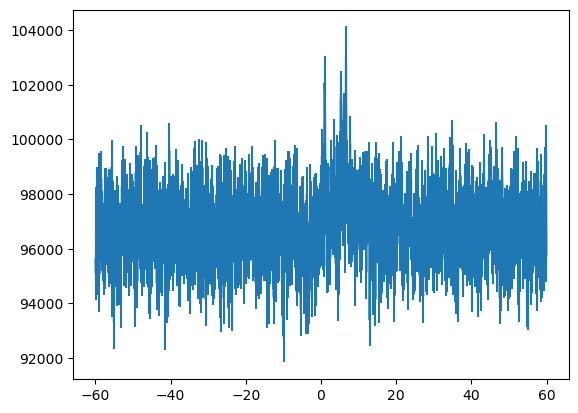

In [7]:
plt.figure()
plt.errorbar(lc['TIME'], lc['RATE'], yerr=lc['ERROR'])

The lightcurve time scale is zero at the centre of the requested time interval, we rescale it to Modified Julian Date

In [8]:
lc['TIME'] =  lc['TIME']/24/3600 + (Time(T1).mjd  + Time(T2).mjd)/2.

In [9]:
lc['TIME'][0:10]

array([59960.20386516, 59960.20386632, 59960.20386748, 59960.20386863,
       59960.20387008, 59960.20387124, 59960.20387211, 59960.20387326,
       59960.20387442, 59960.20387587])

### define a function to rebin the light curve by an entire factor

In [10]:
def rebin(x, n, av=False):
    N = int(len(x)/n)
    if av:
        return np.array(x[:N*n]).reshape((N, n)).mean(1)
    else:
        return np.array(x[:N*n]).reshape((N, n)).sum(1)


Define a time zero at the maximum of the rate to get the background before the putative burst assuming a certain background age

In [15]:
T0_mjd = lc['TIME'][np.argmax(lc['RATE'])]
T0_utc = Time(T0_mjd, format='mjd').iso

# Convert to seconds since T0, special python function
mjd2plot = lambda x:(x - T0_mjd)*24*3600

m_bkg = mjd2plot(lc['TIME']) < -background_age

bkg = np.mean(lc['RATE'][m_bkg])
print('Number of background points: {}, Background rate: {}'.format(np.sum(m_bkg), bkg))

Number of background points: 567, Background rate: 96635.26161081716


In [12]:
m_bkg

array([ True,  True,  True, ..., False, False, False], shape=(1200,))

Make a plot and start preparing the output structure

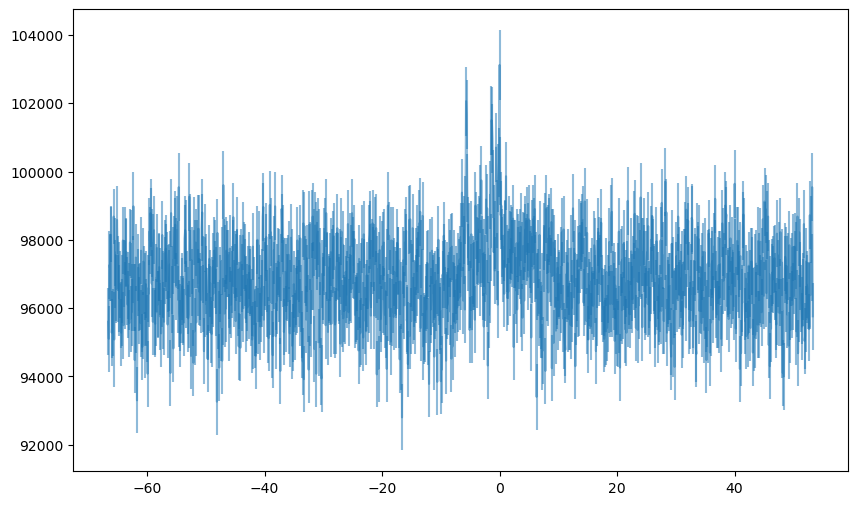

In [17]:
plt.figure(figsize=(10, 6))

plt.errorbar(
    mjd2plot(lc['TIME']),
    lc['RATE'],
    lc['ERROR'],
    label=f"{lc_time_scale} s",
    alpha=0.5,
)

best_detection = {
    'sn': None,
    'timescale': None,
    't_max_sn': None
}


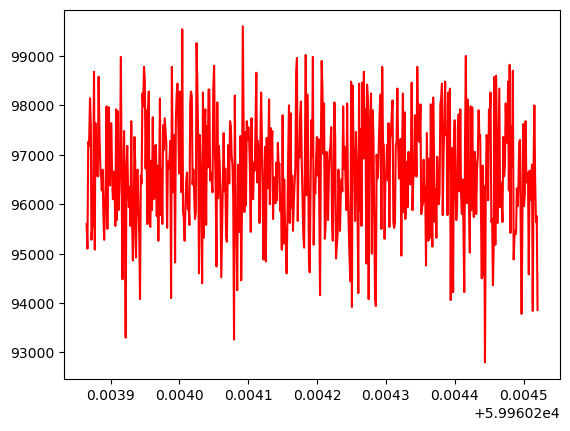

In [16]:
plt.plot(lc['TIME'][m_bkg], lc['RATE'][m_bkg], color='red')

Lopp on different time scales as from input, rebin the light curve and find the highest S/N points at each time scale

10
100


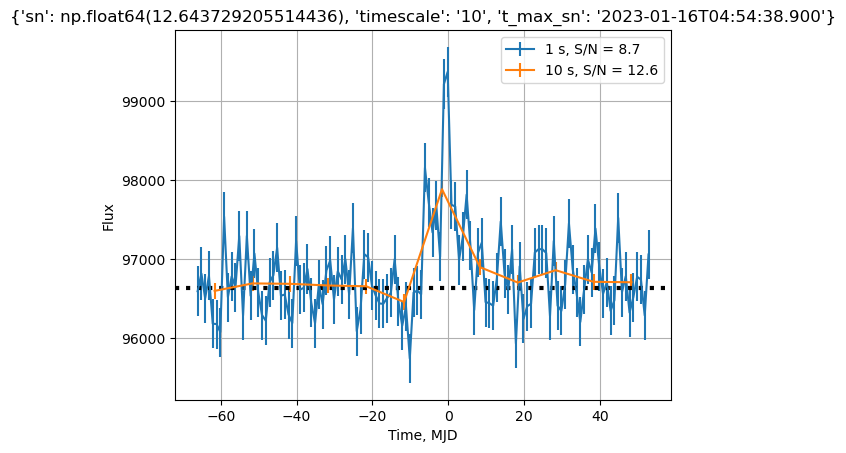

In [18]:
for detection_time_scale in detection_time_scales.split(","):
    n = int(float(detection_time_scale.strip()) / lc_time_scale)
    print(n)
    r_t = rebin(lc['TIME'], n) / n
    r_c = rebin(lc['RATE'], n) / n 
    r_ce = rebin(lc['ERROR']**2, n)**0.5/n
    
    sn = (r_c - bkg) / r_ce
    imax = sn.argmax()
    
    if best_detection['sn'] is None or best_detection['sn'] < sn[imax]:
        best_detection['sn'] = sn[imax]
        best_detection['timescale'] = detection_time_scale
        best_detection['t_max_sn'] = Time(r_t[imax], format='mjd').isot

    plt.errorbar(
        mjd2plot(r_t),
        r_c,
        r_ce,
        label=f"{detection_time_scale} s, S/N = {sn[imax]:.1f}"
    )

    
plt.axhline(bkg, lw=3, ls=":", c="k")
    
plt.grid()
plt.legend()
    
plt.ylabel('Flux')
plt.xlabel('Time, MJD')

plt.title(best_detection)

plt.savefig("annotated-lc.png")

In [19]:
# Convert to seconds since T0_mjd
rel_s = (lc['TIME']-T0_mjd)*24*3600
tstart_rel_mseconds=(Time(T1).mjd - T0_mjd)*24*3600
tstop_rel_seconds=(Time(T2).mjd - T0_mjd)*24*3600

print("total lc",lc.shape)
print("min",lc['TIME'].min()-T0_mjd)
print("max",lc['TIME'].max()-T0_mjd)

b_tb = np.mean(lc['TIME'][1:] - lc['TIME'][:-1])*24*3600 
expected_telapse = tstop_rel_seconds + tstop_rel_seconds 

if len(rel_s) == 0:
    telapse = 0
    ontime = 0
else:
    telapse = rel_s.max() - rel_s.min()
    ontime = np.sum(np.diff(lc['TIME']))*86400
    

print("expected telapse", expected_telapse, "telapse", telapse, "ontime", ontime)

if float(ontime) / expected_telapse < required_completeness:
    raise Exception("data not available: exected %.5lg elapsed %.5lg ontime %.5lg completeness %s requireed %s"%(
        expected_telapse, telapse, ontime,
        ontime / expected_telapse, required_completeness))





total lc (1200,)
min -0.0007708339180680923
max 0.0006168986146803945
expected telapse 106.69998954981565 telapse 119.90009082946926 ontime 119.90009082946926


size (1200,) (1200,)
requested scale 1.0
b_tb 0.10000007575435302
Rebin acceptable, it will be factor 9 for a scale of 0.900001 s
rebinned to (133,)
{ 'excvar': np.float64(51.64897891453052),
  'localfar': np.float64(0.004245064085950232),
  'localfar_s': np.float64(2.8593527788856288),
  'maxrate': np.float64(989643.6947462664),
  'maxsnr': np.float64(3.998164618432733),
  'meanerr': np.float64(104.58273385554921),
  'meanrate': np.float64(967933.7139772614),
  'stdvar': np.float64(5401.591415729218)}
requested scale 10.0
b_tb 0.10000007575435302
Rebin acceptable, it will be factor 99 for a scale of 9.900007 s
rebinned to (12,)
{ 'excvar': np.float64(110.92667042685035),
  'localfar': np.float64(0.013016680318435194),
  'localfar_s': np.float64(2.4833126015195597),
  'maxrate': np.float64(978690.1676905045),
  'maxsnr': np.float64(3.0659981295943104),
  'meanerr': np.float64(31.532993735921217),
  'meanrate': np.float64(967939.2779672068),
  'stdvar': np.float64(3497.8500037164695)}
s

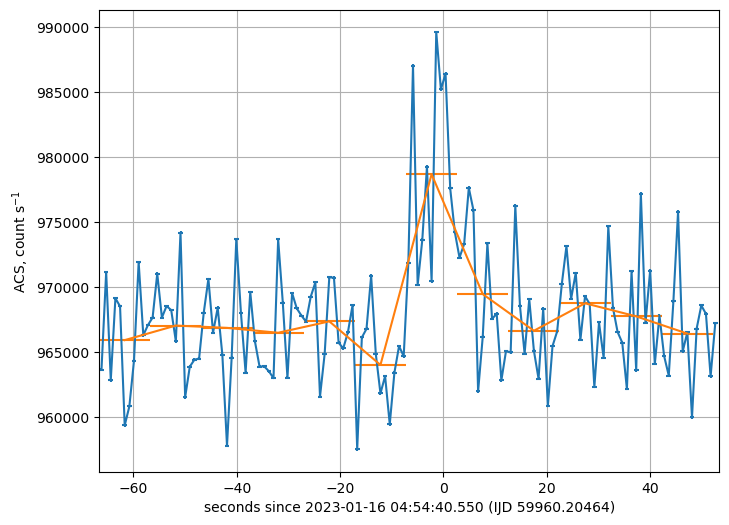

In [20]:
lc_summary = dict()

print("size", lc.shape, rel_s.shape)

plt.figure(figsize=(8,6))


for ascale in [float(x) for x in detection_time_scales.split(",")]:
    summary_scale = dict()
    lc_summary[('s_%.5lg'%ascale).replace(".","_")] = summary_scale        


    print("requested scale",ascale)
    print("b_tb",b_tb)

    if b_tb>ascale:
        ascale = b_tb


    nscale = int(ascale/b_tb)
    scale = nscale*b_tb

    print("Rebin acceptable, it will be factor %d for a scale of %f s" % (nscale, scale))

    rate = rebin(lc['RATE'],nscale)/scale
    rate_err = rebin(lc['ERROR'],nscale)**0.5/scale

    print("rebinned to", rate.shape)

    plt.errorbar(
        rebin(rel_s,nscale,True),
        rate,
        rate_err,
        xerr=scale/2.
    )

    # print(rebin(rel_s,nscale,True)[0:3], scale/4)

    summary_scale['meanrate'] = np.mean(rate)
    summary_scale['maxrate'] = np.max(rate)
    summary_scale['stdvar'] = np.std(rate)
    summary_scale['meanerr'] = np.mean(rate_err**2)**0.5
    summary_scale['excvar'] = summary_scale['stdvar']/summary_scale['meanerr']        

    summary_scale['maxsnr'] = np.max((rate-np.mean(rate))/rate_err/summary_scale['excvar'])

    summary_scale['localfar'] = stats.norm.sf(summary_scale['maxsnr'])*rate.shape[0]

    summary_scale['localfar_s'] = stats.norm.isf(summary_scale['localfar']/2.) if summary_scale['localfar']<1 else 0

    # add FAR spike here

    if 'best' not in lc_summary or summary_scale['localfar_s'] > lc_summary['best']['localfar_s']:
        lc_summary['best'] = dict(
            localfar_s = summary_scale['localfar_s'],
            scale = ascale,
        )

    pprint(summary_scale, indent=2)


#tight_layout()
plt.grid()

plt.xlim(tstart_rel_mseconds, tstop_rel_seconds)
#plt.axhspan(0,10,alpha=0.2,color="red")
#plt.axhspan(10,15,alpha=0.2,color="green")
#plt.axhspan(15,20,alpha=0.2,color="blue")
plt.ylabel("ACS, count s$^{-1}$")
#ylim([0,50])
plt.xlabel("seconds since %s (IJD %.10lg)"%(T0_utc, T0_mjd))

fn="ACS_lc.png"
plt.savefig(fn)
print("saving as",fn)


In [21]:
pprint(lc_summary, indent=2)

{ 'best': {'localfar_s': np.float64(2.8593527788856288), 'scale': 1.0},
  's_1': { 'excvar': np.float64(51.64897891453052),
           'localfar': np.float64(0.004245064085950232),
           'localfar_s': np.float64(2.8593527788856288),
           'maxrate': np.float64(989643.6947462664),
           'maxsnr': np.float64(3.998164618432733),
           'meanerr': np.float64(104.58273385554921),
           'meanrate': np.float64(967933.7139772614),
           'stdvar': np.float64(5401.591415729218)},
  's_10': { 'excvar': np.float64(110.92667042685035),
            'localfar': np.float64(0.013016680318435194),
            'localfar_s': np.float64(2.4833126015195597),
            'maxrate': np.float64(978690.1676905045),
            'maxsnr': np.float64(3.0659981295943104),
            'meanerr': np.float64(31.532993735921217),
            'meanrate': np.float64(967939.2779672068),
            'stdvar': np.float64(3497.8500037164695)}}


## This is a more sophisticated analysis
(note that the code is redundant in some parts)

In [ ]:
# below S/N of 4 FAR is determined primarily by poisson, above - by spikes

def approx_FAR_spike_hz(snr, scale):    
    lim_snr = 2
    
    spike_rate_snr6 = 60./3600./24.
    if scale>=0.1:
        spike_rate_snr6*=(scale/0.1)**-1
    
    
    approx_FAR_hz = snr*0 + spike_rate_snr6 * (lim_snr/6.)**-2.7 
    
    try:
        if snr>lim_snr:
            approx_FAR_hz = spike_rate_snr6 * (np.abs(snr)/6.)**-2.7
    except:
        m=snr>lim_snr
        approx_FAR_hz[m] = (np.abs(snr[m])/6.)**-2.7 * spike_rate_snr6
        

    return approx_FAR_hz

def approx_FAR_norm_hz(snr, scale_s):
    return stats.norm.sf(snr)/scale_s

def approx_FAP(snr, t, scale_s):
    
    try:
        t_scaled = t[:]
        t_scaled[abs(t)<scale_s]=scale_s
    except:
        if abs(t)<scale_s:
            t_scaled=scale_s
        else:
            t_scaled=t

    approx_FAP = 2 * ( approx_FAR_norm_hz(snr, scale_s) + approx_FAR_spike_hz(snr, scale_s) )  * abs(t_scaled) * (1+np.log( 30/0.1))
    
    return approx_FAP


In [ ]:
plt.figure()

x=np.linspace(-5,10,100)

for scale_s in 0.05, 0.1, 1, 10:

    c=plt.plot(x,approx_FAR_norm_hz(x, scale_s), ls='--')
    p=plt.plot(x,approx_FAR_spike_hz(x, scale_s),c=c[0].get_color(),ls=":")
    plt.plot(x,
               approx_FAR_spike_hz(x, scale_s) + approx_FAR_norm_hz(x, scale_s),
               c=c[0].get_color()
              )


    plt.semilogy()

plt.ylim([1e-5, 30])

In [ ]:
timescales = sorted(set([0.05*ns for ns in sorted(set(
    list(map(int,np.logspace(0,np.log10(20*30),100))) 
))]  + list(np.linspace(1,31,30*2+1))))
timescales

In [ ]:
summary = dict()    
all_excesses=[]            

best_lc=None


rel_s = (lc['TIME']-T0_mjd)*24*3600
m = rel_s>-tstart_rel_mseconds
m &= rel_s<tstop_rel_seconds

print("total lc",lc.shape)
print("min",(lc['TIME'].min()-T0_mjd)*86400)
print("max",(lc['TIME'].max()-T0_mjd)*86400)

b_tb = np.mean(lc['TIME'][1:]-lc['TIME'][:-1]) * 24 * 3600

expected_telapse = tstop_rel_seconds + tstop_rel_seconds    

if len(rel_s) == 0:
    telapse = 0
    ontime = 0
else:
    telapse = rel_s.max() - rel_s.min()
    ontime = np.sum(lc['TIME'][1:]-lc['TIME'][:-1]) * 24 * 3600

print("expected telapse", expected_telapse, "telapse", telapse, "ontime", ontime)

if ontime / expected_telapse < required_completeness:
    raise Exception("data not available: exected %.5lg elapsed %.5lg ontime %.5lg"%(expected_telapse, telapse, ontime))
    
lc_summary = dict()
summary['ACS']=lc_summary

print("size", lc.shape, rel_s.shape)

plt.figure(figsize=(8,6))

best_lc_byscale={}

#for ascale in [0.05, 0.1, 0.2, 0.5, 1, 2, 10]:
for ascale in timescales:
# for ascale in [0.05, 0.1, 0.5]:
#for ascale in [0.05*i for i in range(20)] + [0.5*i for i in range(20)] + [15, 20, 25, 30]:
#for ascale in [0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 1, 2, 8, 10]:
#for ascale in [1,]:
    s_scale_mo = {}
    lc_summary[('s_%.5lg'%ascale).replace(".","_")] = s_scale_mo    
    
    
    print("requested scale",ascale)
#        print("b_tb",b_tb)
    
    if b_tb>ascale:
        ascale = b_tb
                
    
    nscale = int(round(ascale/b_tb))
    scale=nscale*b_tb

    print("true scale", scale)
    
#        print("acceptable, will be", nscale, scale)
    
    c = None
    
    #for offset in range(0,nscale):            
    #for offset in (, round(nscale/2)):            
    
    if nscale < 20:
        offsets = range(0, round(nscale/2)+1)
    else:
        offsets = range(0, round(nscale/2)+1, max(round(round(nscale/2)/20), 1))
    
    for offset in offsets: 
        summary_scale = dict()
        s_scale_mo[offset]=summary_scale
        
        rel_s_scale = rebin(rel_s[offset:], nscale, True)
        rate = rebin(lc['RATE'][offset:],nscale,False)/scale        
        rate_err = rebin(lc['ERROR'][offset:],nscale,False)**0.5/scale

        #print("rebinned to",rate.shape)
        print("offset", offset, "rebinned to",rate.shape)
        
        
        summary_scale['scale_s']=scale
        summary_scale['meanrate'] = np.mean(rate)
        summary_scale['maxrate'] = np.max(rate)            
        summary_scale['stdvar'] = np.std(rate)
        summary_scale['meanerr'] = np.mean(rate_err**2)**0.5
        summary_scale['excvar'] = summary_scale['stdvar']/summary_scale['meanerr']        

        print("summary_scale['excvar']", summary_scale['excvar'])

        if negative_excesses==1:
            snr = -(rate-np.mean(rate))/rate_err/summary_scale['excvar']
        else:
            snr = (rate-np.mean(rate))/rate_err/summary_scale['excvar']
        
        i_max = np.argmax(snr)
        
        print(i_max,snr[i_max],rel_s_scale[i_max])
        
        summary_scale['maxsnr'] = snr[i_max]
        summary_scale['maxsnr_t'] = rel_s_scale[i_max]

        summary_scale['localfar'] = stats.norm.sf(summary_scale['maxsnr'])*rate.shape[0]

        summary_scale['localfar_s'] = stats.norm.isf(summary_scale['localfar']/2.) if summary_scale['localfar']<1 else 0
        
        m_over_threshold = snr > global_snr_threshold
                    
        excesses = dict(
                        snr = snr[m_over_threshold],
                        rel_s_scale = rel_s_scale[m_over_threshold],
                        rate = rate[m_over_threshold],
                        rate_err = rate_err[m_over_threshold],
                        rate_overbkg = rate[m_over_threshold] - np.mean(rate),
                    )
                    
        summary_scale['excesses'] = [dict(zip(excesses.keys(), er)) for er in zip(*excesses.values())]

        for e in summary_scale['excesses']:
            e['FAP'] = approx_FAP(e['snr'], e['rel_s_scale'], scale)
        
        all_excesses+=[
                    dict(scale=scale, offset=offset,excess=e) for e in summary_scale['excesses']
                ]

        print("scale", scale, "offset", offset, "found excesses",len(summary_scale['excesses']))                        

        #r=plt.errorbar(
        #    rebin(rel_s[offset:],nscale,True),
        #    rate,
        #    rate_err,
        #    xerr=scale/4.,
        #    c=c,
        #    alpha=0.7
        #)
        
    #    print(rel_s_scale.shape, snr.shape)
        
        r = plt.errorbar(
            rel_s_scale,
            snr,
            snr*0+1,
            xerr=scale/2.,
            c=c,
            alpha=0.7
        )
        
        plt.axvline(summary_scale['maxsnr_t'],c="k")
        
        c=r[0].get_color()
        
        # add FAR spike here

        if 'best' not in lc_summary or summary_scale['localfar_s'] > lc_summary['best']['localfar_s']:
            lc_summary['best'] = dict(
                localfar_s = summary_scale['localfar_s'],
                scale = ascale,
                summary_scale = summary_scale,
            )
            best_lc=rel_s_scale,rate,rate_err
        
        if 'best' not in s_scale_mo or summary_scale['localfar_s'] > s_scale_mo['best']['localfar_s']:
            s_scale_mo['best'] = dict(
                localfar_s = summary_scale['localfar_s'],
                scale = ascale,
                summary_scale = summary_scale,
            )
            #  best_lc=rel_s_scale,rate,rate_err
        
        if ascale not in best_lc_byscale or summary_scale['localfar_s'] > best_lc_byscale[ascale]['localfar_s']:
            best_lc_byscale[ascale] = dict(
                localfar_s = summary_scale['localfar_s'],
                scale = ascale,
                summary_scale = summary_scale,
                best_lc=(rel_s_scale,rate,rate_err),
            )
            
    
        #print(summary_scale)
    s_scale_mo.update(s_scale_mo['best']['summary_scale'])

#tight_layout()
plt.grid()

#plt.xlim(-tstart_rel_mseconds, tstop_rel_seconds)
#plt.axhspan(0,10,alpha=0.2,color="red")
#plt.axhspan(10,15,alpha=0.2,color="green")
#plt.axhspan(15,20,alpha=0.2,color="blue")
plt.ylabel("ACS S/N")
#ylim([0,50])
plt.xlabel("seconds since %s (IJD %.10lg)"%(T0_utc, T0_mjd))
#plt.xlim([-10, 10])

detfn="ACS_det_lc.png"
plt.savefig(detfn)
print("saving as",detfn)
    
summary['ACS']['best']

In [ ]:
for e in all_excesses:
    # print(e['scale'], e['excess']['snr'], e['excess']['FAP'])
    if np.abs(e['scale'] - 0.1)< 0.001:
        # if np.abs(e['excess']['rel_s_scale']) < 5:
        print(e['excess']['rel_s_scale'], e)

In [ ]:
grouped_excesses = []

for i in sorted(all_excesses, key=lambda x:x['excess']['FAP']):
    if i['excess']['FAP']<1 or True:
        print(i['scale'],i['offset'], i['excess']['snr'], i['excess']['rel_s_scale'], i['excess']['FAP'])
        
        grouped=False
        for g in grouped_excesses:
            if abs(i['excess']['rel_s_scale']-g['excess']['rel_s_scale'])<max(i['scale'],g['scale']):
                print("to group", g['excess']['rel_s_scale'])
                if i['excess']['snr'] > g['excess']['snr']:
                    print("group takeover")
                    g.update(i)
                grouped=True
                
        if not grouped:
            print("new group")
            #i['group']=[i]
            grouped_excesses.append(i)

In [ ]:
grouped_excesses=sorted(grouped_excesses, key=lambda x:x['excess']['FAP'])

for i in grouped_excesses:
    print(f"timescale {i['scale']:4.2f}   S/N {i['excess']['snr']:5.2f}   T0+{i['excess']['rel_s_scale']:7.1f}   FAP {i['excess']['FAP']:7.5f}")

In [ ]:
summary['ACS']['best']

In [ ]:
summary['ACS']['s_8']

In [ ]:
excvar_summary=dict(
)

for k,s in summary['ACS'].items():
    if 'scale_s' in s:
        print("%.5lg"%s['scale_s'], "%5.4lg"%s['excvar'])
        
        if s['scale_s']<=0.200:
            kg='hf_200ms'
        elif s['scale_s']<=2.00:
            kg='mf_200ms_2s'
        elif s['scale_s']<=10.00:
            kg='mf_2s_10s'
        else:
            kg='lf_10s'
        
        if kg not in excvar_summary:
            excvar_summary[kg]=[s['excvar']]
        else:
            excvar_summary[kg]+=[s['excvar']]

for k,v in excvar_summary.items():
    print(k,min(v),max(v))

In [ ]:
fig_names=[]


for limit_group in 0.02, 0.1, 1: 
    figs=dict()
    
    rel_s = (lc['TIME']-T0_mjd)*24*3600
    m = rel_s>-tstart_rel_mseconds
    m &= rel_s<tstop_rel_seconds

    print("total lc",lc.shape)
    print("min",(lc['TIME'].min()-T0_mjd)*86400)
    print("max",(lc['TIME'].max()-T0_mjd)*86400)

    #rel_s = rel_s[m]

    for excess in grouped_excesses:
        #if excess['excess']['FAP'] > 0.02: continue
        if excess['excess']['FAP'] > limit_group: continue

        print(excess)


        offset = excess['offset']
        nscale = int(excess['scale']/b_tb)  
        scale=excess['scale']

        s_figs = sorted(figs.items(), key=lambda x:abs(x[0]-scale))

        if len(s_figs) == 0 or s_figs[0][0] < scale*0.5 or s_figs[0][0] > scale*1.5: 
            fig = plt.figure(figsize=(8,6))
            figs[scale] = fig
            plt.xlim([-2,2])
            plt.xlabel("seconds since "+T0_utc)
            plt.ylabel("counts/s")
            plt.title("FAP threshold %.5lg"%limit_group)
        else:            
            print("good match", s_figs[0][0], scale)
            plt.figure(s_figs[0][1].number)
            plt.xlabel("seconds since "+T0_utc)
            plt.ylabel("counts/s")



        rel_s_scale = rebin(rel_s[offset:],nscale,True)
        rate = rebin(lc['RATE'][offset:],nscale,False)/scale        
        rate_err = rebin(lc['ERROR'][offset:],nscale,False)**0.5/scale

        bkg=np.mean(rate)

        m_on = np.abs(rel_s_scale-excess['excess']['rel_s_scale'])<excess['scale']*1.5


        plt.grid(False)

        plt.axhline(0, alpha=0.2, ls=":", color='gray')

        cr=plt.errorbar(
                rel_s_scale, 
                (rate-bkg), 
                (rate_err),
                alpha=0.5,
                ls="",
            )[0].get_color()

        plt.step(
                rel_s_scale, 
                (rate-bkg), 
            #      (rate_err),
                alpha=0.5,
                where="mid",
                c=cr,
            )

        plt.axhline(np.std(rate)*3, alpha=0.2, ls="--",c=cr)
        plt.axhline(np.std(rate)*5, alpha=0.2, ls="--", lw=2,c=cr)


        plt.errorbar(
                rel_s_scale[m_on], 
                (rate-bkg)[m_on], 
                (rate_err)[m_on],
                lw=2.,
                alpha=1,
                label="S/N %.3lg FAP %.3lg scale %.3lg s"%(excess['excess']['snr'],excess['excess']['FAP'],excess['scale']),
                c=cr
            )

        newlim=([
            min([excess['excess']['rel_s_scale']*1.3-excess['scale']*5,-excess['scale']*5]),
            max([excess['excess']['rel_s_scale']*1.3+excess['scale']*5,excess['scale']*5]),
        ])

        oldlim=plt.gca().get_xlim()

        print(oldlim)

        plt.xlim([
            min([oldlim[0],newlim[0]]),
            max([oldlim[1],newlim[1]]),
        ])


for f_i,(s,f) in enumerate(figs.items()):
    f.legend()
    f.gca().axvline(0,ls="--",c="r",lw=3)
    fn="excess_%.5lg_%i.png"%(s,len(fig_names))
    f.savefig(fn)
    fig_names.append(fn)






## Add the significance of association to a GW event
reference documents: 

- Savchenko et al. 2017 https://iopscience.iop.org/article/10.3847/2041-8213/aa8f94/pdf
- Savchenko et al. 2012 https://www.aanda.org/articles/aa/pdf/2012/05/aa18877-12.pdf
- Abbott et al 2017 https://iopscience.iop.org/article/10.3847/2041-8213/aa920c/pdf

Essentially, it is necessary to define the rate of similar events and multiply it for the temporal distance from the GW trigger. 

Inserting the ranking of spike following Savchenko et al. 2012 might be too much, we can use events with similar duration and similar S/N in the orbit, see appendix A of Savchenko et al. (2017)
